In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [3]:
plt.style.use('ggplot')

# Load the training and test datasets
df = pd.read_csv('small.csv')
#test_df = pd.read_csv('test.csv')

print(df.shape)

(100000, 7)


In [5]:
example = df['cons'][19]
print(example)

tokens = nltk.word_tokenize(example)
tagged = nltk.pos_tag(tokens) # tags each token with a set of predetermined codes from NLTK documentation


- Morale low due to constant threat of layoffs over the years. At one point I was told 'meets expectation' became the new 'exceeds expectations'. More recently managers told they must give some percentage of employees 'below expectation' rating . erate employees one on one or in public. Should not silently mock (make faces) while employees that are dialed in are speaking.


In [6]:
entities = nltk.chunk.ne_chunk(tagged) # chunks the words with their codes
# entities.pprint() # pretty printing !

from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

sia = SentimentIntensityAnalyzer()


In [7]:
# We will now run the polarity_scores function on first 1000 rows
res = {}
for i, row in tqdm(df.iloc[:1000].iterrows(), total=1000):
    text = row['pros'] + row['cons']
    res[i] = sia.polarity_scores(text)

# Convert the results into a DataFrame
vaders = pd.DataFrame(res).T

# Reset index and merge with original DataFrame 'df'
vaders = vaders.reset_index().rename(columns={'index': 'i'})
vaders = vaders.merge(df, how='left', left_on='i', right_index=True)

100%|██████████| 1000/1000 [00:00<00:00, 6941.30it/s]


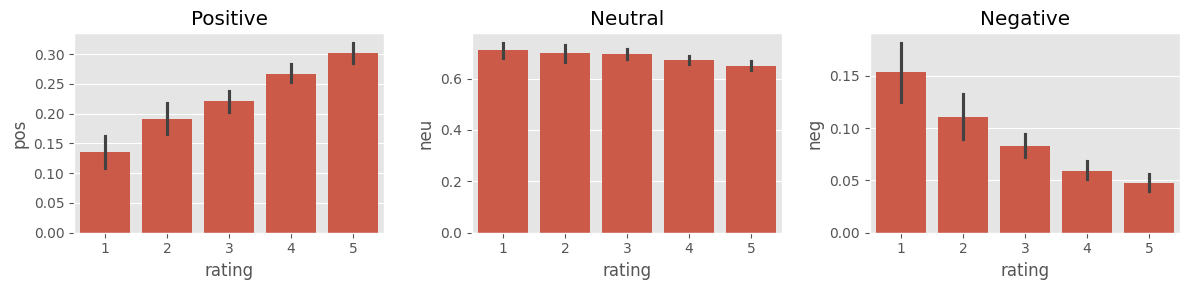

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='rating', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='rating', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='rating', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

In [11]:
# Roberta Pretrained Model:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [12]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

print(example)
print(sia.polarity_scores(example))


- Morale low due to constant threat of layoffs over the years. At one point I was told 'meets expectation' became the new 'exceeds expectations'. More recently managers told they must give some percentage of employees 'below expectation' rating . erate employees one on one or in public. Should not silently mock (make faces) while employees that are dialed in are speaking.
{'neg': 0.116, 'neu': 0.849, 'pos': 0.035, 'compound': -0.9186}


In [14]:
# Now we attempt to run the roBERTa model on it (based on Google's 2018 BERT model)
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

print(polarity_scores_roberta(example))

{'roberta_neg': 0.6113591, 'roberta_neu': 0.35411766, 'roberta_pos': 0.034523185}


In [15]:
# Iterate for all the scores:
res = {}
for i, row in tqdm(df.iloc[:1000].iterrows(), total=1000):
    try:
        text = row['pros'] + row['cons']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[i] = both
    except RuntimeError:
        print(f'Broke for index {i}')

results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'i'})
results_df = results_df.merge(df, how='left', left_on='i', right_index=True)

print(results_df.columns)


 22%|██▎       | 225/1000 [00:07<00:26, 28.80it/s]

Broke for index 221


100%|██████████| 1000/1000 [00:33<00:00, 29.61it/s]

Index(['i', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'rating', 'year_review',
       'firm', 'job_title', 'headline', 'pros', 'cons'],
      dtype='object')


In [21]:
print(df.iloc[221])

rating                                                         2
year_review                                                 2015
firm                                                   Microsoft
job_title                            Principal Applied Scientist
headline                                career stops at level 65
pros           good place to join as a junior, if you work ha...
cons           microsoft decided to cut the lead role last ye...
Name: 221, dtype: object


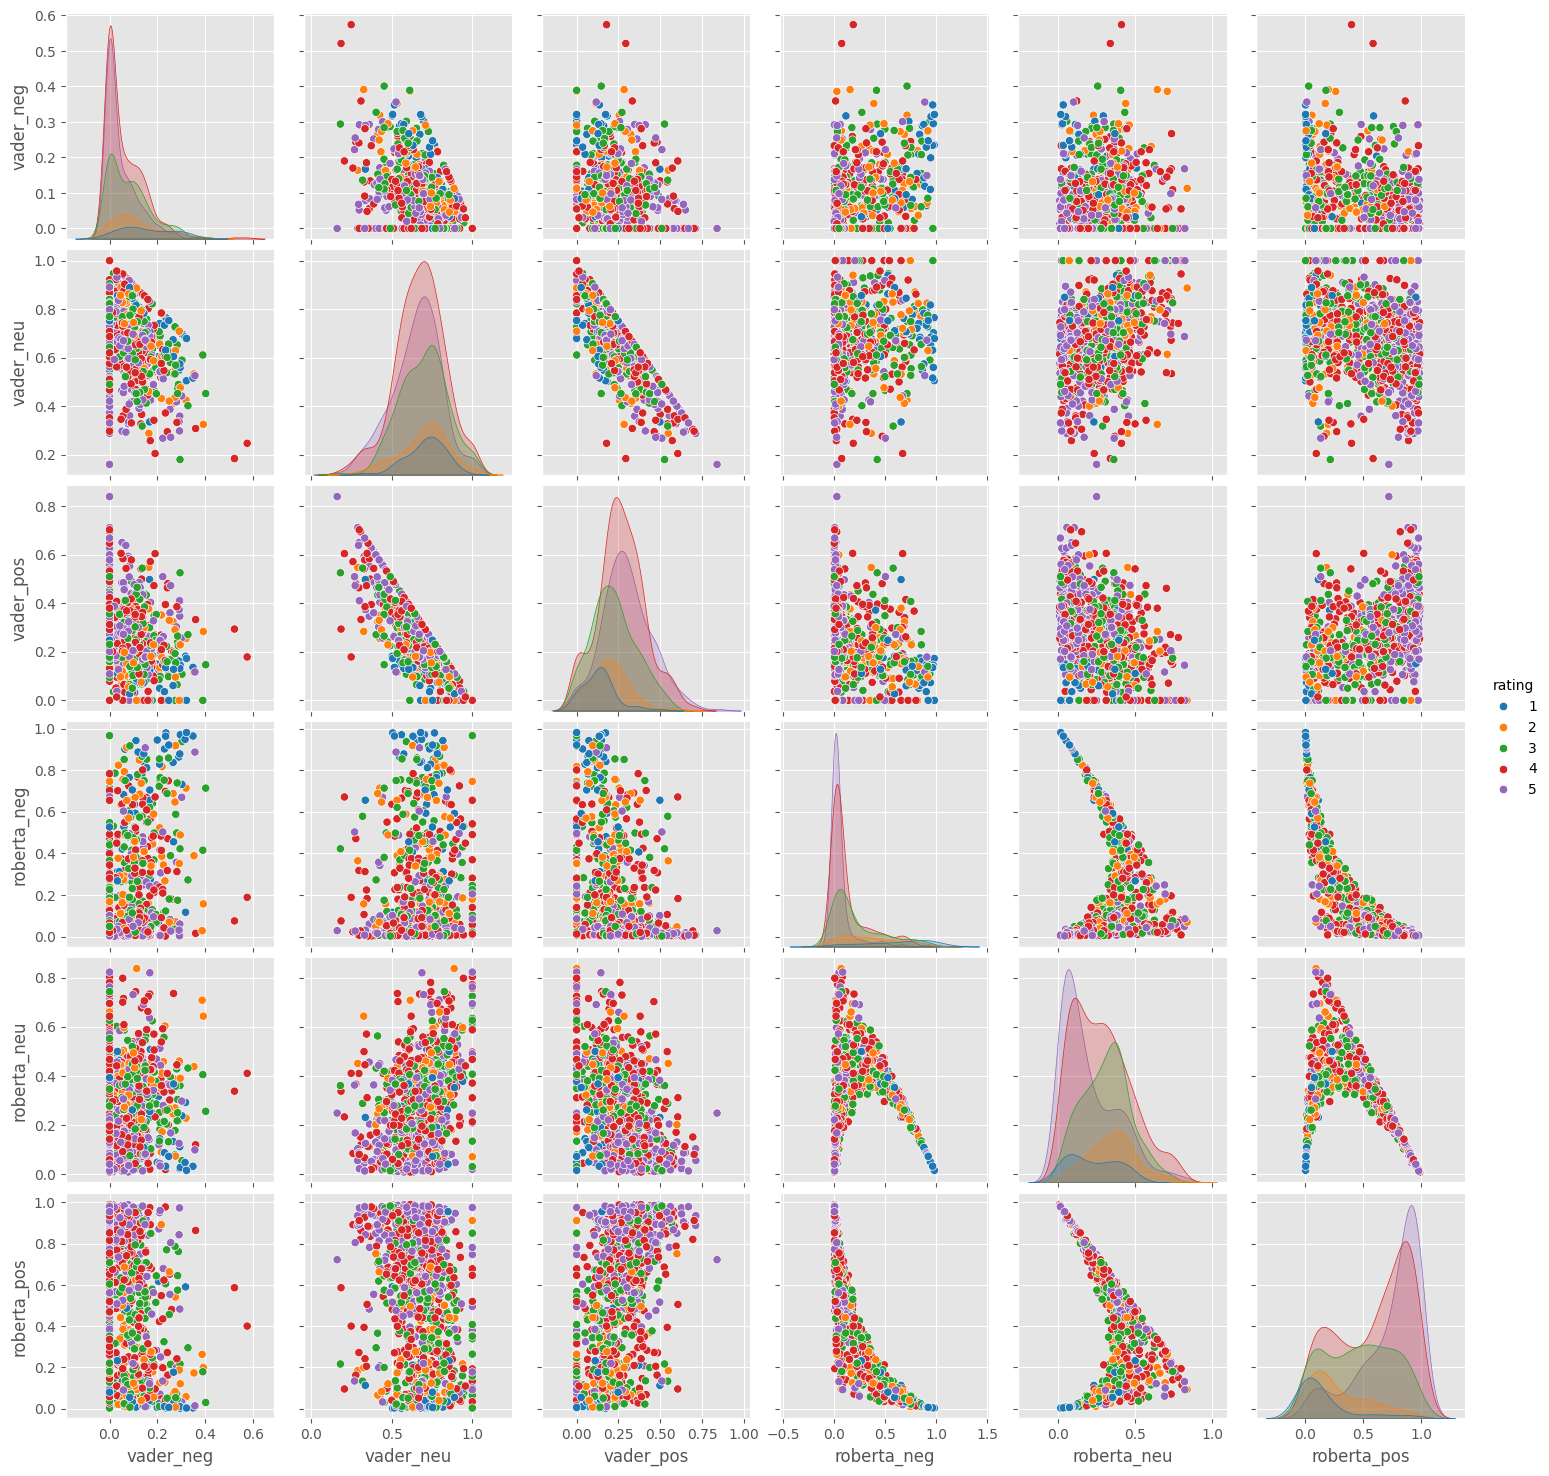

In [23]:
sns.pairplot(data=results_df,
             vars=['vader_neg', 'vader_neu', 'vader_pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='rating',
            palette='tab10')
plt.show()

In [31]:
# Reviewing outlier examples:
results_df.query('rating == 1') \
    .sort_values('roberta_pos', ascending=False)['cons'].values[0]


'I had 4 bosses in one year.  GBS can be a body shop.'

In [32]:
results_df.query('rating == 1') \
    .sort_values('vader_pos', ascending=False)['cons'].values[0]


'Senior Management are not knowledgeable, have terrible man management and nasty.'

In [33]:
# Opposite case:
results_df.query('rating == 5') \
    .sort_values('roberta_neg', ascending=False)['cons'].values[0]

'Low pay, horrible management along with upper mgt also. They do not care about employes. All the mgt cares about is making their bonus. Nothing more nothing less.'

In [34]:
results_df.query('rating == 5') \
    .sort_values('vader_pos', ascending=False)['cons'].values[0]

'Not enough clear growth opportunity'